Saving archive (3).zip to archive (3) (2).zip
Dataset Loaded Successfully
                             Patient_ID  Age     Sex Family_History  \
0  b2a49170-8561-4665-9371-2240b55dd87a   31    Male             No   
1  f5fae45d-8718-41c4-a957-6928f79f3c8e   33  Female            Yes   
2  66ab0567-050b-4d56-9ec4-b676309899a6   69    Male            Yes   
3  996a48e4-e841-418f-a539-5a7a86cd815d   66    Male            Yes   
4  d45c7ca8-7125-4aaa-8018-5bbc60d35a1f   43  Female            Yes   

   HTT_CAG_Repeat_Length Motor_Symptoms Cognitive_Decline  Chorea_Score  \
0                     67       Moderate            Severe          8.80   
1                     38         Severe          Moderate          3.24   
2                     37         Severe          Moderate          1.01   
3                     50           Mild            Severe          3.21   
4                     48       Moderate              Mild          2.31   

   Brain_Volume_Loss  Functional_Capacity  ... H

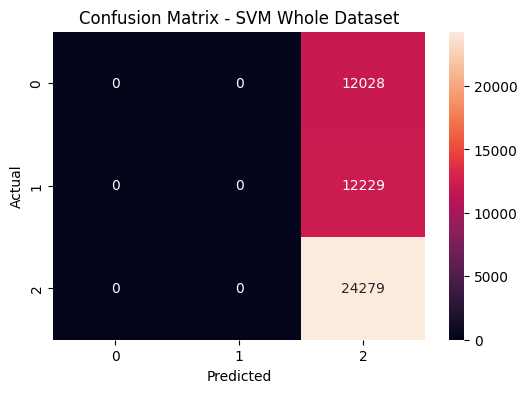

In [ ]:
# libraries
import pandas as pd
import zipfile
import os
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# upload and load dataset
uploaded = files.upload()
zip_filename = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall("/content/")

csv_file = [f for f in os.listdir("/content/") if f.endswith(".csv")][0]
df = pd.read_csv(os.path.join("/content/", csv_file))
print("Dataset Loaded Successfully")
print(df.head())

# cleaning
df = df.ffill()
df = df.drop(columns=[
    "Patient_ID","Function","Effect","Gene/Factor",
    "Chromosome_Location","Random_Protein_Sequence","Random_Gene_Sequence"
], errors='ignore')

# label encoding
for col in df.select_dtypes(include="object"):
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# features and target
X = df.drop(columns=["Category"])  # Use all other columns as features
y = df["Category"]

# scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# train SVM on whole dataset
model = SVC(kernel='rbf', random_state=42)
model.fit(X_scaled, y)
y_pred = model.predict(X_scaled)

# evaluation
acc = accuracy_score(y, y_pred)
prec = precision_score(y, y_pred, average='weighted', zero_division=0)
rec = recall_score(y, y_pred, average='weighted')
f1 = f1_score(y, y_pred, average='weighted')

print(f"\nSVM Trained on Whole Dataset")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")

# confusion matrix
cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - SVM Whole Dataset")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Saving archive (3).zip to archive (3) (1).zip
Dataset Loaded Successfully

SVM Trained on Whole Dataset (Linear Kernel)
Accuracy: 0.5002
Precision: 0.2502
Recall: 0.5002
F1 Score: 0.3336


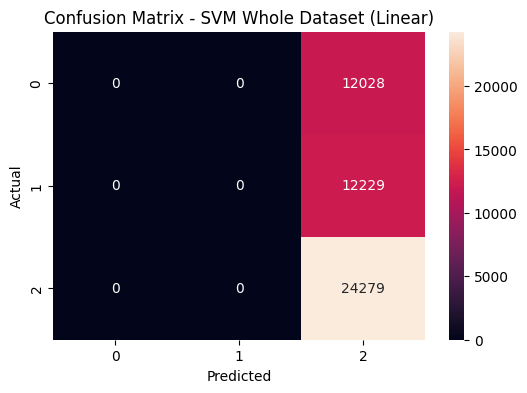

In [ ]:
# libraries
import pandas as pd
import zipfile
import os
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# upload and load dataset
uploaded = files.upload()
zip_filename = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall("/content/")

csv_file = [f for f in os.listdir("/content/") if f.endswith(".csv")][0]
df = pd.read_csv(os.path.join("/content/", csv_file))
print("Dataset Loaded Successfully")

# cleaning
df = df.ffill()
df = df.drop(columns=[
    "Patient_ID","Function","Effect","Gene/Factor",
    "Chromosome_Location","Random_Protein_Sequence","Random_Gene_Sequence"
], errors='ignore')

# label encoding
for col in df.select_dtypes(include="object"):
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# features and target
X = df.drop(columns=["Category"])  # use all other columns as features
y = df["Category"]

# scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# faster SVM using linear kernel
model = SVC(kernel='linear', random_state=42)
model.fit(X_scaled, y)
y_pred = model.predict(X_scaled)

# evaluation
acc = accuracy_score(y, y_pred)
prec = precision_score(y, y_pred, average='weighted', zero_division=0)
rec = recall_score(y, y_pred, average='weighted')
f1 = f1_score(y, y_pred, average='weighted')

print(f"\nSVM Trained on Whole Dataset (Linear Kernel)")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")

# confusion matrix
cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - SVM Whole Dataset (Linear)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
